# Lead Scoring — Modelling, Calibration, Interpretation

The EDA notebook framed three things that drive the choices here:

1. ~15.5% positive class — moderate imbalance. I'll use class weighting
   and threshold-aware metrics rather than aggressive resampling.
2. `PageValues` is partly derived from the conversion outcome, so it can
   leak future information. Every model is trained twice — **with** and
   **without** PageValues — so the reader can see what's achievable
   purely from pre-conversion features.
3. `*_Duration` and the matching count features are correlated. A
   tree-based model handles this cleanly; the LR baseline gets L2
   regularisation as insurance.

The plan:

* Logistic regression baseline (linear, interpretable lower bound).
* LightGBM with stratified 5-fold CV on the train split.
* Isotonic calibration on a held-out validation slice.
* SHAP for global and per-prediction explanations.
* Top-decile precision and cumulative gains — the metrics that translate
  to "who do we actually call first".


## 1. Setup

In [1]:
import sys
import warnings
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb
import shap
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold

from src.data import load
from src.features import (
    prepare, make_split, build_lr_pipeline,
    NUMERICAL_COLS, CATEGORICAL_COLS,
)
from src.evaluation import (
    basic_metrics, top_k_precision, metrics_table,
    plot_calibration, plot_cumulative_gains, lift_curve_data,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42


/Users/achrafhalla/Downloads/online-shoppers-lead-scoring/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load data and split

Stratified 80/20 split — the test set is held out for the final
evaluation only. Cross-validation and calibration use the train portion.


In [2]:
df = load()
X, y = prepare(df)
X_train, X_test, y_train, y_test = make_split(X, y, random_state=RANDOM_STATE)

print(f"Train: {len(X_train):,} rows, base rate {y_train.mean():.3%}")
print(f"Test:  {len(X_test):,} rows, base rate {y_test.mean():.3%}")


Train: 9,864 rows, base rate 15.470%
Test:  2,466 rows, base rate 15.491%


## 3. Logistic regression baseline

A linear model with class weighting establishes the floor. If a tree
model can't beat this, something is wrong with the tree or its
hyperparameters.

In [3]:
lr_pipe = build_lr_pipeline(class_weight="balanced", C=1.0)
lr_pipe.fit(X_train, y_train)
lr_test_score = lr_pipe.predict_proba(X_test)[:, 1]

print("Logistic regression — test set:")
for k, v in basic_metrics(y_test, lr_test_score).items():
    print(f"  {k}: {v:.4f}")
print(f"  prec@top10%: {top_k_precision(y_test, lr_test_score, 0.1):.4f}")


Logistic regression — test set:
  roc_auc: 0.8932
  pr_auc: 0.6224
  brier: 0.1241
  prec@top10%: 0.7073


## 4. LightGBM with stratified CV

LightGBM handles categoricals natively (no one-hot blowup) and is
robust to the correlated count/duration pairs. Stratified 5-fold CV
on train gives an honest read on variance before we touch the test set.


In [4]:
def lgbm_params() -> dict:
    return dict(
        objective="binary",
        metric="average_precision",
        learning_rate=0.05,
        num_leaves=31,
        feature_fraction=0.9,
        bagging_fraction=0.9,
        bagging_freq=5,
        min_data_in_leaf=20,
        is_unbalance=True,
        verbose=-1,
        random_state=RANDOM_STATE,
    )


def cv_lightgbm(X, y, n_splits=5):
    """Stratified CV — returns per-fold metrics and OOF predictions."""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    oof = np.zeros(len(y))
    fold_metrics = []
    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        train_set = lgb.Dataset(X_tr, label=y_tr, categorical_feature=CATEGORICAL_COLS)
        val_set = lgb.Dataset(X_va, label=y_va, categorical_feature=CATEGORICAL_COLS)
        booster = lgb.train(
            lgbm_params(),
            train_set,
            num_boost_round=2000,
            valid_sets=[val_set],
            callbacks=[lgb.early_stopping(50, verbose=False)],
        )
        oof[va_idx] = booster.predict(X_va)
        m = basic_metrics(y_va, oof[va_idx])
        m["fold"] = fold
        m["best_iter"] = booster.best_iteration
        fold_metrics.append(m)
    return pd.DataFrame(fold_metrics), oof


fold_df, oof = cv_lightgbm(X_train, y_train)
print(fold_df.round(4))
print("\nMean across folds:")
print(fold_df[["roc_auc", "pr_auc", "brier"]].mean().round(4))


   roc_auc  pr_auc   brier  fold  best_iter
0   0.9297  0.7489  0.1020     1         80
1   0.9327  0.7472  0.0874     2         82
2   0.9275  0.7268  0.0907     3        134
3   0.9372  0.7640  0.0873     4         89
4   0.9372  0.7633  0.0875     5         69

Mean across folds:
roc_auc    0.9329
pr_auc     0.7500
brier      0.0910
dtype: float64


### Refit on full train, predict on test

In [5]:
best_iter = int(round(fold_df["best_iter"].mean()))
print(f"Refitting on full train with num_boost_round={best_iter}")

train_set_full = lgb.Dataset(X_train, label=y_train, categorical_feature=CATEGORICAL_COLS)
booster_full = lgb.train(
    lgbm_params(),
    train_set_full,
    num_boost_round=best_iter,
)
lgbm_test_score = booster_full.predict(X_test)

print("\nLightGBM — test set:")
for k, v in basic_metrics(y_test, lgbm_test_score).items():
    print(f"  {k}: {v:.4f}")
print(f"  prec@top10%: {top_k_precision(y_test, lgbm_test_score, 0.1):.4f}")


Refitting on full train with num_boost_round=91

LightGBM — test set:
  roc_auc: 0.9317
  pr_auc: 0.7425
  brier: 0.0944
  prec@top10%: 0.7805


## 5. The PageValues experiment

Repeat the same modelling without `PageValues`. The drop in PR-AUC tells
us how much of the model's apparent skill comes from a feature that
partially encodes the outcome. In a real-time scoring system, you'd use
PageValues from the user's *prior* sessions only — but that's a data
question, not a model question.

In [6]:
X_np, y_np = prepare(df, drop_pagevalues=True)
X_train_np, X_test_np, y_train_np, y_test_np = make_split(
    X_np, y_np, random_state=RANDOM_STATE
)

# Logistic regression without PageValues
lr_np = build_lr_pipeline(class_weight="balanced", drop_pagevalues=True)
lr_np.fit(X_train_np, y_train_np)
lr_np_score = lr_np.predict_proba(X_test_np)[:, 1]

# LightGBM CV without PageValues
fold_df_np, oof_np = cv_lightgbm(X_train_np, y_train_np)
best_iter_np = int(round(fold_df_np["best_iter"].mean()))
booster_np = lgb.train(
    lgbm_params(),
    lgb.Dataset(X_train_np, label=y_train_np, categorical_feature=CATEGORICAL_COLS),
    num_boost_round=best_iter_np,
)
lgbm_np_score = booster_np.predict(X_test_np)


### Side-by-side comparison

In [7]:
scores_full = {
    "Logistic regression (with PV)": lr_test_score,
    "Logistic regression (no PV)": lr_np_score,
    "LightGBM (with PV)": lgbm_test_score,
    "LightGBM (no PV)": lgbm_np_score,
}

table = metrics_table(y_test, scores_full)
print(table)


                               roc_auc  pr_auc   brier  prec@top10%  \
model                                                                 
Logistic regression (with PV)   0.8932  0.6224  0.1241       0.7073   
Logistic regression (no PV)     0.7348  0.3211  0.2145       0.3821   
LightGBM (with PV)              0.9317  0.7425  0.0944       0.7805   
LightGBM (no PV)                0.7755  0.3649  0.1769       0.4228   

                               prec@top20%  prec@top30%  
model                                                    
Logistic regression (with PV)       0.5416       0.4235  
Logistic regression (no PV)         0.3428       0.2923  
LightGBM (with PV)                  0.5923       0.4587  
LightGBM (no PV)                    0.3550       0.3315  


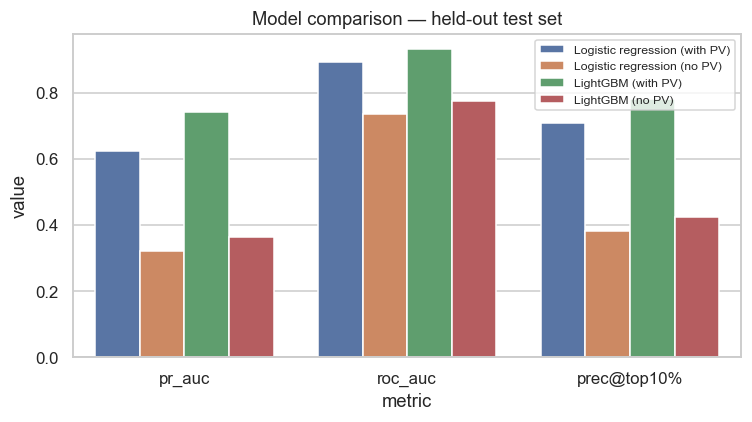

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
table_long = table.reset_index().melt(id_vars="model",
                                      value_vars=["pr_auc", "roc_auc",
                                                  "prec@top10%"],
                                      var_name="metric", value_name="value")
sns.barplot(data=table_long, x="metric", y="value", hue="model", ax=ax)
ax.set_title("Model comparison — held-out test set")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "10_model_comparison.png", bbox_inches="tight")
plt.show()


## 6. Calibration

LightGBM's raw probabilities are not necessarily well-calibrated.
`is_unbalance=True` shifts them, and tree models in general can be
over-confident at the extremes. I fit isotonic regression on a held-out
validation slice from the train set, then evaluate calibration on the
test set.

In [9]:
# Carve a validation slice out of train for the calibrator
from sklearn.model_selection import train_test_split as tts

X_tr2, X_val, y_tr2, y_val = tts(
    X_train, y_train, test_size=0.2,
    stratify=y_train, random_state=RANDOM_STATE
)

booster_for_calib = lgb.train(
    lgbm_params(),
    lgb.Dataset(X_tr2, label=y_tr2, categorical_feature=CATEGORICAL_COLS),
    num_boost_round=best_iter,
)

# Isotonic mapping fit on validation, applied to test
from sklearn.isotonic import IsotonicRegression
iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(booster_for_calib.predict(X_val), y_val)

lgbm_test_raw = booster_for_calib.predict(X_test)
lgbm_test_iso = iso.transform(lgbm_test_raw)

calib_scores = {
    "LightGBM raw": lgbm_test_raw,
    "LightGBM + isotonic": lgbm_test_iso,
    "Logistic regression": lr_test_score,
}

print(metrics_table(y_test, calib_scores))


                     roc_auc  pr_auc   brier  prec@top10%  prec@top20%  \
model                                                                    
LightGBM raw          0.9310  0.7416  0.0928       0.7886       0.5903   
LightGBM + isotonic   0.9288  0.7032  0.0717       0.7439       0.5801   
Logistic regression   0.8932  0.6224  0.1241       0.7073       0.5416   

                     prec@top30%  
model                             
LightGBM raw              0.4601  
LightGBM + isotonic       0.4560  
Logistic regression       0.4235  


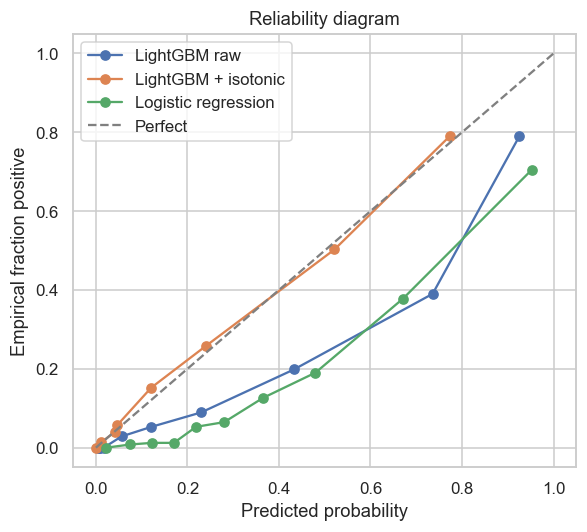

In [10]:
fig, ax = plt.subplots(figsize=(5.5, 5))
plot_calibration(y_test, calib_scores, n_bins=10, ax=ax)
plt.tight_layout()
plt.savefig(FIG_DIR / "11_calibration.png", bbox_inches="tight")
plt.show()


## 7. Cumulative gains

The lift chart shows what fraction of the converters are captured if
sales contacts the top X% of leads. The 45° line is "call everyone at
random"; the higher the curve sits above it, the more the model is
worth the engineering effort.

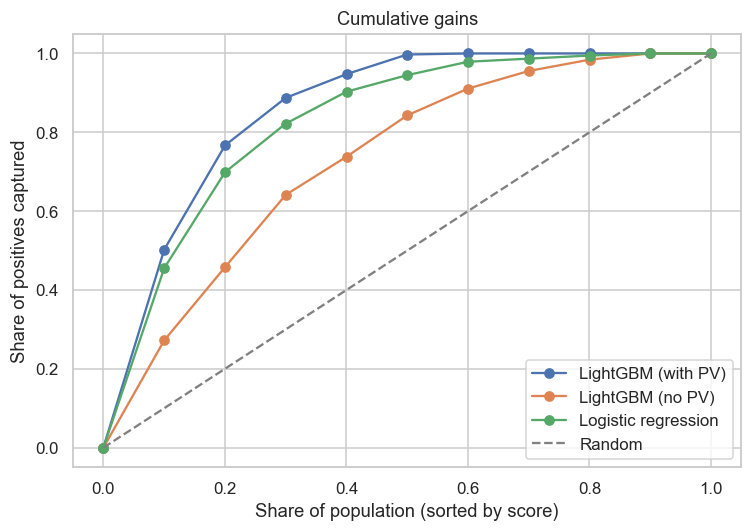

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_cumulative_gains(y_test, {
    "LightGBM (with PV)": lgbm_test_score,
    "LightGBM (no PV)": lgbm_np_score,
    "Logistic regression": lr_test_score,
}, ax=ax)
plt.tight_layout()
plt.savefig(FIG_DIR / "12_cumulative_gains.png", bbox_inches="tight")
plt.show()


In [12]:
# Decile table — useful in a sales conversation
deciles = lift_curve_data(y_test, lgbm_test_score, n_bins=10)
deciles[["n", "positives", "cum_share_pop", "cum_share_pos",
         "cum_precision", "lift"]].round(3)


,n,positives,cum_share_pop,cum_share_pos,cum_precision,lift
bin,,,,,,
1,247,192,0.1,0.503,0.777,5.018
2,247,101,0.2,0.767,0.593,3.829
3,246,46,0.3,0.887,0.458,2.957
4,247,23,0.4,0.948,0.367,2.368
5,246,19,0.5,0.997,0.309,1.995
6,247,1,0.6,1.000,0.258,1.666
7,246,0,0.7,1.000,0.221,1.429
8,247,0,0.8,1.000,0.194,1.250
9,246,0,0.9,1.000,0.172,1.111


## 8. SHAP — what the model is actually doing

Two questions:

1. **Globally**, which features drive the score? (Bar plot of mean
   |SHAP|.)
2. **Locally**, why did *this* lead get the score it did? (One example
   each from the high-confidence positive and false-positive buckets.)

Local explanations are the part sales/marketing actually want when they
ask "why is this contact ranked so high?".

In [13]:
# Use the no-PageValues model for SHAP — the explanation is more
# informative when the dominant near-leakage feature is removed.
explainer = shap.TreeExplainer(booster_np)
shap_values = explainer.shap_values(X_test_np)

# Some SHAP versions return [neg, pos]; some return a single array.
if isinstance(shap_values, list):
    shap_values = shap_values[1]
print("SHAP values shape:", shap_values.shape)


SHAP values shape: (2466, 16)


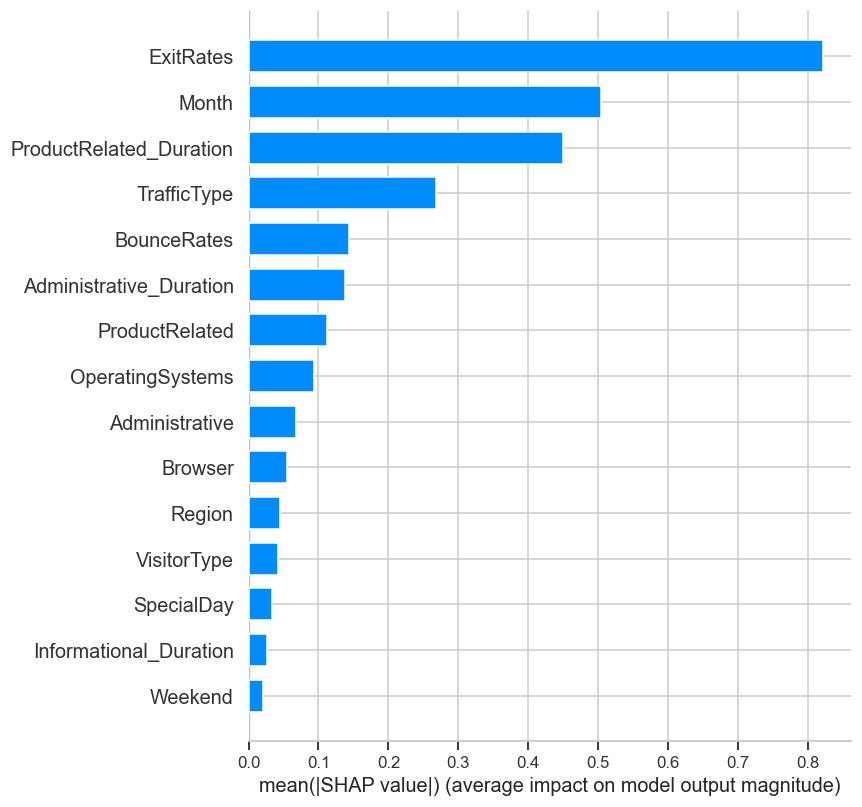

In [14]:
fig = plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_test_np, plot_type="bar", show=False, max_display=15)
plt.tight_layout()
plt.savefig(FIG_DIR / "13_shap_global_bar.png", bbox_inches="tight")
plt.show()


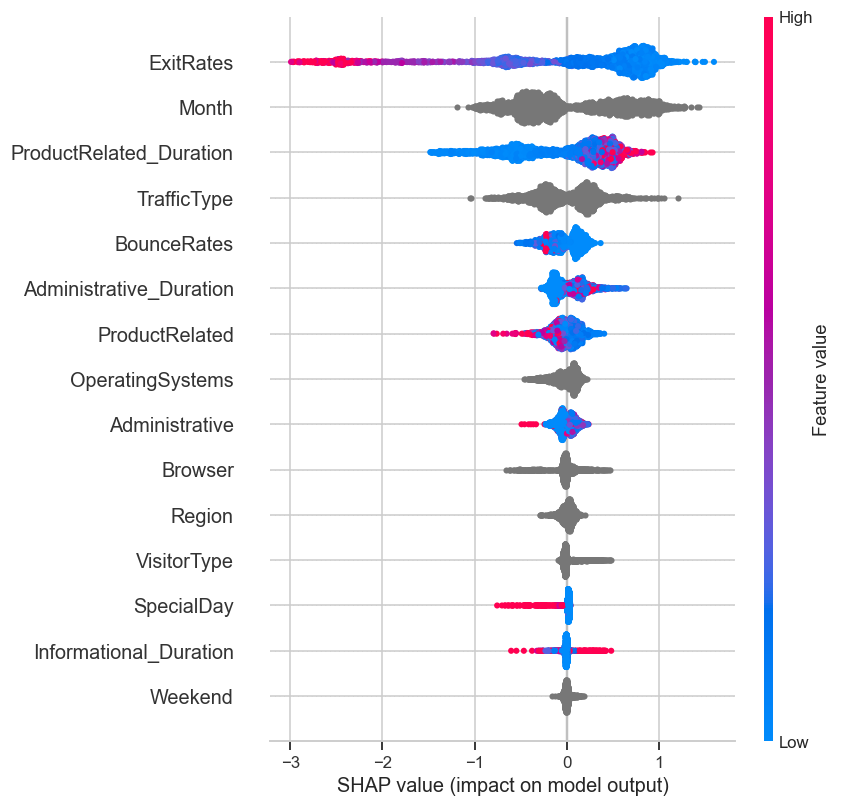

In [15]:
fig = plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_test_np, show=False, max_display=15)
plt.tight_layout()
plt.savefig(FIG_DIR / "14_shap_summary.png", bbox_inches="tight")
plt.show()


### Local explanation — a high-confidence positive prediction

Row 900: predicted prob = 0.874, actual = True


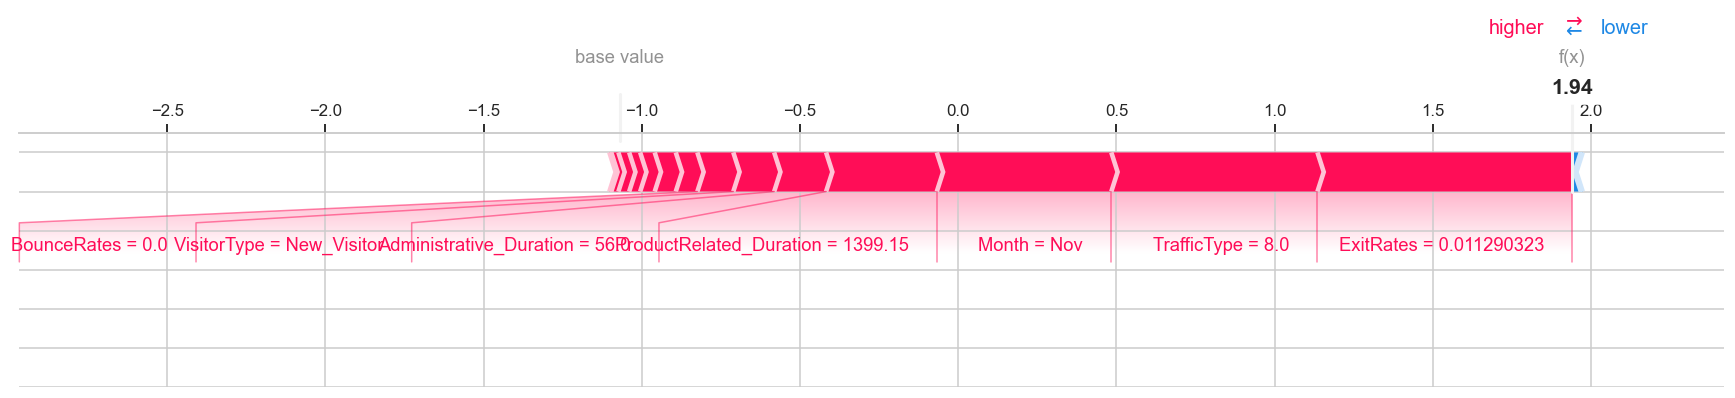

In [16]:
high_conf_idx = int(np.argmax(lgbm_np_score))
print(f"Row {high_conf_idx}: predicted prob = {lgbm_np_score[high_conf_idx]:.3f}, "
      f"actual = {bool(y_test_np.iloc[high_conf_idx])}")

shap.force_plot(
    explainer.expected_value, shap_values[high_conf_idx],
    X_test_np.iloc[high_conf_idx], matplotlib=True, show=False
)
plt.savefig(FIG_DIR / "15_shap_force_positive.png", bbox_inches="tight")
plt.show()


### Local explanation — a false positive (model said yes, customer didn't convert)

Row 1006: predicted prob = 0.874, actual = False


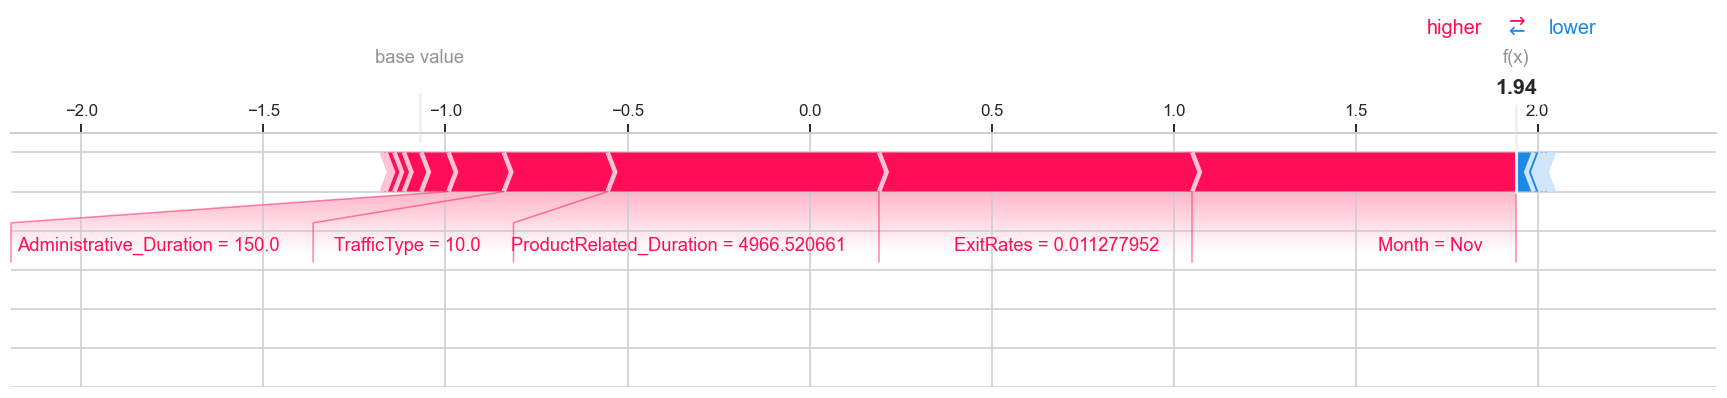

In [17]:
# False positives: predicted high, actually negative
fp_mask = (y_test_np.values == 0)
fp_scores = np.where(fp_mask, lgbm_np_score, -np.inf)
fp_idx = int(np.argmax(fp_scores))
print(f"Row {fp_idx}: predicted prob = {lgbm_np_score[fp_idx]:.3f}, "
      f"actual = {bool(y_test_np.iloc[fp_idx])}")

shap.force_plot(
    explainer.expected_value, shap_values[fp_idx],
    X_test_np.iloc[fp_idx], matplotlib=True, show=False
)
plt.savefig(FIG_DIR / "16_shap_force_false_positive.png", bbox_inches="tight")
plt.show()
